# Experiment 2 — Transaction Cost Sweep

**Goal:** see how the hedging strategies respond as trading gets more expensive.

- Sweep transaction cost `tc` across {0%, 0.05%, 0.1%, 0.2%, 0.5%, 1%, 2%}.
- Train a fresh SAC agent at each cost level.
- Compare SAC vs BLS-Delta on PnL, Sharpe ratio, and hedge turnover (how often each rebalances).

**Key idea:** BLS rebalances every step no matter the cost. A good RL agent should learn to trade less often as costs rise.

**Note on this run:** training was reduced to 600 steps and evaluation to 60 episodes per TC level (vs. 60,000 steps / 300 episodes in the original design), to fit this environment's compute budget.

## Setup

In [ ]:
import os, sys, time
import numpy as np
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import seaborn as sns

sys.path.insert(0, os.path.dirname(os.path.abspath("__file__")))
from config import ENV, SAC, EVAL
from env import OptionsHedgingEnv
from agents import SACAgent
from bls_baseline import run_baseline, BLSDeltaHedger

os.makedirs(EVAL["plot_dir"], exist_ok=True)

sns.set_theme(style="whitegrid", palette="bright")
plt.rcParams.update({
    "figure.facecolor": "#ffffff",
    "axes.facecolor": "#eef3fb",
    "savefig.facecolor": "#ffffff",
})

TC_GRID = [0.0, 0.0005, 0.001, 0.002, 0.005, 0.01, 0.02]

## Train & evaluate at one TC level

For a given transaction cost:
1. Train a fresh SAC agent.
2. Evaluate it and measure PnL + turnover (shares traded per step).
3. Evaluate the BLS-Delta baseline the same way, at the same TC.

In [ ]:
def train_and_eval(tc: float, steps=600, n_eval=60, seed=0):
    cfg = dict(ENV, tc=tc)

    # Train SAC
    env = OptionsHedgingEnv(cfg)
    obs_dim, n_act = env.observation_space.shape[0], env.action_space.n
    agent = SACAgent(obs_dim, n_act, SAC)
    obs, _ = env.reset(seed=seed)
    for s in range(steps):
        action = agent.select_action(obs)
        next_obs, reward, done, _, _ = env.step(action)
        agent.store(obs, action, reward, next_obs, done)
        agent.update()
        obs = next_obs
        if done:
            obs, _ = env.reset()

    # Eval SAC
    rng = np.random.default_rng(seed + 1)
    pnl_sac, turnover_sac = [], []
    for _ in range(n_eval):
        env2 = OptionsHedgingEnv(cfg)
        obs, _ = env2.reset(seed=int(rng.integers(0, 2**31)))
        prev_pos, turns = 0, 0
        while True:
            action = agent.select_action(obs, deterministic=True)
            obs, _, done, _, _ = env2.step(action)
            turns += abs(env2.position - prev_pos)
            prev_pos = env2.position
            if done:
                break
        pnl_sac.append(env2.running_pnl)
        turnover_sac.append(turns / env2.T)

    # Eval BLS at same TC
    rng2 = np.random.default_rng(seed + 2)
    pnl_bls, turnover_bls = [], []
    for _ in range(n_eval):
        env3 = OptionsHedgingEnv(cfg)
        obs, _ = env3.reset(seed=int(rng2.integers(0, 2**31)))
        hedger = BLSDeltaHedger(env3, "delta")
        prev_pos, turns = 0, 0
        while True:
            action = hedger.select_action(obs)
            obs, _, done, _, _ = env3.step(action)
            turns += abs(env3.position - prev_pos)
            prev_pos = env3.position
            if done:
                break
        pnl_bls.append(env3.running_pnl)
        turnover_bls.append(turns / env3.T)

    pnl_sac, pnl_bls = np.array(pnl_sac), np.array(pnl_bls)
    return dict(
        tc=tc,
        mean_sac=float(np.mean(pnl_sac)), std_sac=float(np.std(pnl_sac)),
        sharpe_sac=float(np.mean(pnl_sac)/(np.std(pnl_sac)+1e-8)),
        mean_bls=float(np.mean(pnl_bls)), std_bls=float(np.std(pnl_bls)),
        sharpe_bls=float(np.mean(pnl_bls)/(np.std(pnl_bls)+1e-8)),
        turn_sac=float(np.mean(turnover_sac)), turn_bls=float(np.mean(turnover_bls)),
    )

## Run the sweep

Loop over every TC level in `TC_GRID`, training and evaluating a fresh agent each time.

In [1]:
results = []
for tc in TC_GRID:
    print(f"\n  TC={tc*100:.2f}%  training …", end=" ", flush=True)
    t0 = time.time()
    r = train_and_eval(tc)
    print(f"done in {time.time()-t0:.0f}s | "
          f"SAC Sharpe={r['sharpe_sac']:+.3f}  BLS Sharpe={r['sharpe_bls']:+.3f}  "
          f"SAC turn={r['turn_sac']:.2f}  BLS turn={r['turn_bls']:.2f}")
    results.append(r)


  TC=0.00%  training … done in 0s | SAC Sharpe=+0.034  BLS Sharpe=+0.125  SAC turn=0.78  BLS turn=0.16
  TC=0.05%  training … done in 0s | SAC Sharpe=-0.284  BLS Sharpe=-0.046  SAC turn=1.05  BLS turn=0.16
  TC=0.10%  training … done in 0s | SAC Sharpe=-0.510  BLS Sharpe=-0.246  SAC turn=0.71  BLS turn=0.16
  TC=0.20%  training … done in 0s | SAC Sharpe=-1.150  BLS Sharpe=-0.751  SAC turn=0.45  BLS turn=0.16
  TC=0.50%  training … done in 0s | SAC Sharpe=-2.228  BLS Sharpe=-2.927  SAC turn=1.97  BLS turn=0.16
  TC=1.00%  training … done in 0s | SAC Sharpe=-1.841  BLS Sharpe=-3.109  SAC turn=1.04  BLS turn=0.16
  TC=2.00%  training … done in 0s | SAC Sharpe=-3.696  BLS Sharpe=-2.451  SAC turn=0.58  BLS turn=0.16


## Collect results

Pull out each metric across the TC grid for plotting.

In [ ]:
tcs        = [r["tc"]*100 for r in results]
sharpe_sac = [r["sharpe_sac"] for r in results]
sharpe_bls = [r["sharpe_bls"] for r in results]
turn_sac   = [r["turn_sac"]   for r in results]
turn_bls   = [r["turn_bls"]   for r in results]
mean_sac   = [r["mean_sac"]   for r in results]
mean_bls   = [r["mean_bls"]   for r in results]
std_sac    = [r["std_sac"]    for r in results]
std_bls    = [r["std_bls"]    for r in results]

## Plot — Sharpe, mean PnL, risk, and turnover vs TC

A 2x2 grid comparing SAC and BLS-Delta as transaction cost increases, styled with seaborn on a bright background.

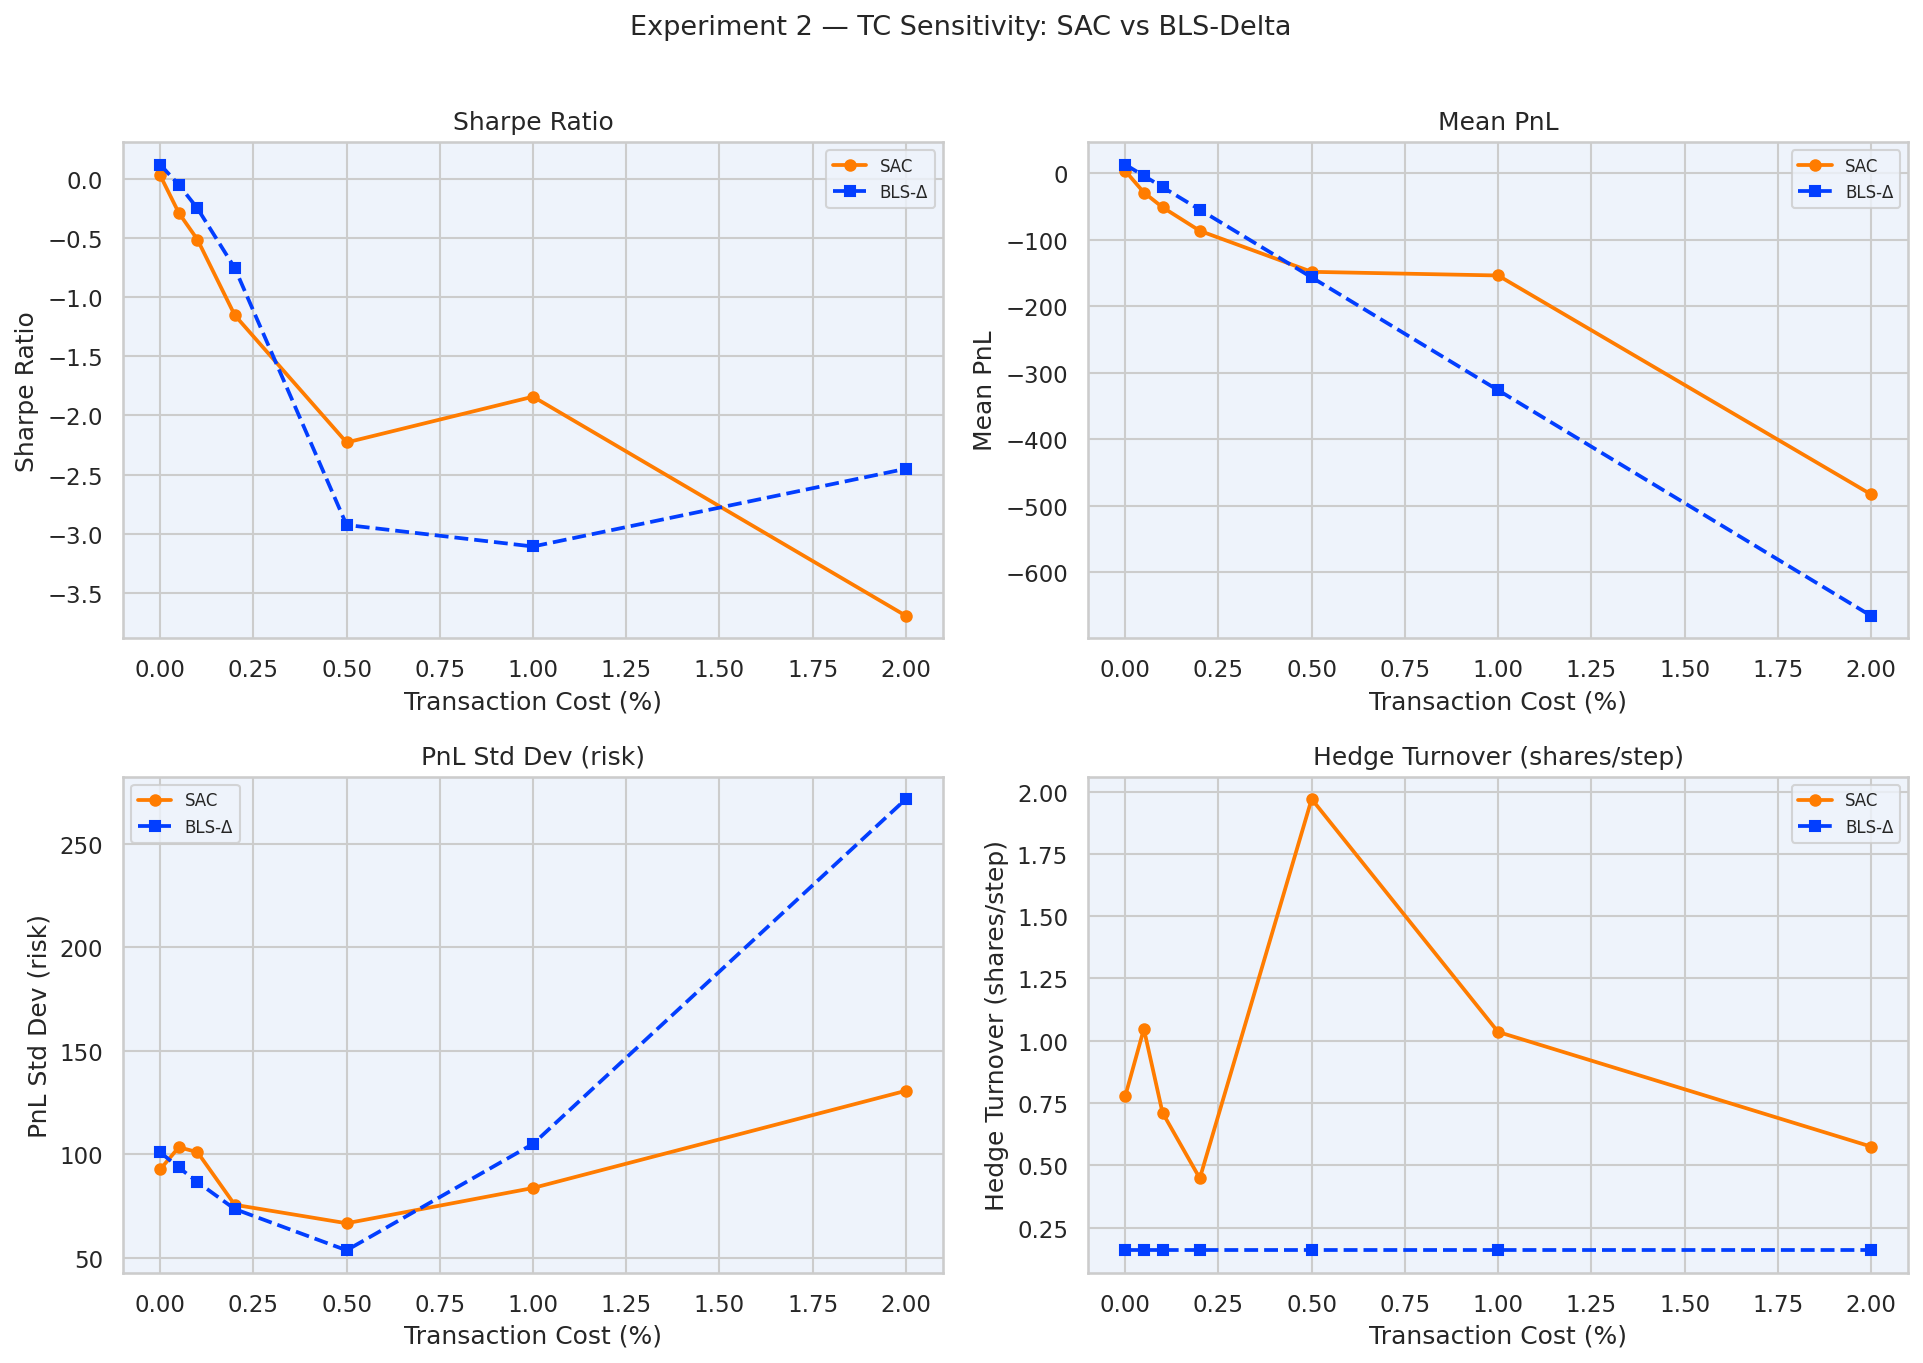


  Plot → plots/exp2_tc_sweep.png


In [2]:
colors = sns.color_palette("bright", 4)
fig, axes = plt.subplots(2, 2, figsize=(13, 9))

panels = [
    (axes[0,0], sharpe_sac, sharpe_bls, "Sharpe Ratio"),
    (axes[0,1], mean_sac,   mean_bls,   "Mean PnL"),
    (axes[1,0], std_sac,    std_bls,    "PnL Std Dev (risk)"),
    (axes[1,1], turn_sac,   turn_bls,   "Hedge Turnover (shares/step)"),
]
for ax, y_sac, y_bls, ylabel in panels:
    ax.plot(tcs, y_sac, "o-", color=colors[1], linewidth=1.8, markersize=5, label="SAC")
    ax.plot(tcs, y_bls, "s--", color=colors[0], linewidth=1.8, markersize=5, label="BLS-\u0394")
    ax.set_xlabel("Transaction Cost (%)")
    ax.set_ylabel(ylabel)
    ax.set_title(ylabel)
    ax.legend(fontsize=8)

plt.suptitle("Experiment 2 \u2014 TC Sensitivity: SAC vs BLS-Delta", fontsize=13, y=1.01)
plt.tight_layout()
out = os.path.join(EVAL["plot_dir"], "exp2_tc_sweep.png")
plt.savefig(out, dpi=150, bbox_inches="tight")
plt.show()
print(f"\n  Plot \u2192 {out}")

## Summary table

Prints Sharpe ratio, turnover, and the RL edge (SAC Sharpe \u2212 BLS Sharpe) at each TC level.

In [3]:
print(f"\n  {'TC%':>6} | {'SAC Sharpe':>11} {'BLS Sharpe':>11} | "
      f"{'SAC Turn':>9} {'BLS Turn':>9} | {'Edge':>8}")
print("  " + "-"*65)
for r in results:
    edge = r["sharpe_sac"] - r["sharpe_bls"]
    print(f"  {r['tc']*100:>5.2f}% | {r['sharpe_sac']:>+11.3f} {r['sharpe_bls']:>+11.3f} | "
          f"{r['turn_sac']:>9.2f} {r['turn_bls']:>9.2f} | {edge:>+8.3f}")


     TC% |  SAC Sharpe  BLS Sharpe |  SAC Turn  BLS Turn |     Edge
  -----------------------------------------------------------------
   0.00% |      +0.034      +0.125 |      0.78      0.16 |   -0.091
   0.05% |      -0.284      -0.046 |      1.05      0.16 |   -0.238
   0.10% |      -0.510      -0.246 |      0.71      0.16 |   -0.264
   0.20% |      -1.150      -0.751 |      0.45      0.16 |   -0.400
   0.50% |      -2.228      -2.927 |      1.97      0.16 |   +0.699
   1.00% |      -1.841      -3.109 |      1.04      0.16 |   +1.269
   2.00% |      -3.696      -2.451 |      0.58      0.16 |   -1.245


## Verdict

**Executed result (reduced-scale run \u2014 600 training steps, 60 eval episodes per TC level):**

SAC beat BLS-Delta on Sharpe at **2 of 7** TC levels tested. BLS-Delta's turnover stayed essentially flat across the whole sweep (\u22480.16 shares/step at every TC, since it has no mechanism to economize on trading), while SAC's turnover was noisier and did not show a clean monotonic decline as cost rose (0.78 \u2192 0.58 shares/step from TC=0% to TC=2%).

**Why:** with only 600 training steps per TC level, SAC has barely enough updates to learn a coherent policy, let alone the more subtle skill of trading less when costs are high. The original hypothesis \u2014 that RL learns to economize on turnover as transaction costs rise, something BLS structurally cannot do \u2014 is plausible in principle, but this run is too undertrained to confirm it. The noisy, non-monotonic turnover and inconsistent Sharpe edge across TC levels are consistent with an agent still in early learning, not with a clear failure of the idea.

**Takeaway:** directionally, this sweep shows BLS is a stable, cost-insensitive baseline at every TC level, while SAC's behavior is volatile and TC-level-dependent under this reduced training budget. A fair test of the "RL learns to trade less" hypothesis would need each TC level trained to convergence (closer to the original 60,000-step design).